In [1]:
from pathlib import Path

STATS_DIR = Path(__name__).resolve().parents[1] / "stats" / "scottish_stats"

In [2]:
## Code for Bootstrap confidence intervals


import json
import numpy as np
import os

def percentile_bootstrap_ci_from_json_in_cwd(
    filename,
    candidate_size=None,   
    B=5000,
    alpha=0.05,
    seed=0
):
    path = os.path.join(STATS_DIR, filename)

    with open(path, "r") as f:
        obj = json.load(f)

    # collect values
    if candidate_size is None:
        vals = []
        for k, d in obj.items():            
            vals.extend(d.values())
    else:
        k = str(candidate_size)
        if k not in obj:
            raise KeyError(f"candidate_size={candidate_size} not found. Available: {sorted(obj.keys(), key=int)}")
        vals = list(obj[k].values())

    x = np.asarray(vals, dtype=float)
    n = len(x)
    if n == 0:
        raise ValueError("No values found.")

    # bootstrap means
    rng = np.random.default_rng(seed)
    boot = np.empty(B, dtype=float)
    for b in range(B):
        idx = rng.integers(0, n, size=n)
        boot[b] = x[idx].mean()

    boot_sorted = np.sort(boot)

    
    lo_idx = int(np.floor(alpha * B / 2.0))
    hi_idx = int(np.ceil((1.0 - alpha / 2.0) * B)) - 1

    lo_idx = max(0, min(B - 1, lo_idx))
    hi_idx = max(0, min(B - 1, hi_idx))

    L = float(boot_sorted[lo_idx])
    U = float(boot_sorted[hi_idx])

    return boot.tolist(), (L, U)


In [3]:
def build_bootstrap_csv_for_rules(
    metric_dir="sigma_IIA_average",
    rules=("stv", "plurality", "borda"),
    B=1000,
    alpha=0.05,
    seed=0,
    out_csv="bootstrap_cis_sigma_IIA_average.csv"
):
    rows = []

    base = os.path.join(
        STATS_DIR,
        metric_dir,
    )

    for rule in rules:
        rule_dir = os.path.join(base, rule)
        if not os.path.exists(rule_dir):
            print(f"Skipping missing rule: {rule}")
            continue

        json_files = [f for f in os.listdir(rule_dir) if f.endswith(".json")]

        for jf in json_files:
            rel_path = os.path.join(metric_dir, rule, jf)

            if "__TIEBREAK_" in jf:
                tiebreak = jf.split("__TIEBREAK_", 1)[1].split("_output.json")[0]
            else:
                tiebreak = "unknown"

            with open(os.path.join(STATS_DIR, rel_path), "r") as f:
                obj = json.load(f)

            candidate_sizes = sorted(obj.keys(), key=int)

            _, (L, U) = percentile_bootstrap_ci_from_json_in_cwd(
                rel_path,
                candidate_size=None,
                B=B,
                alpha=alpha,
                seed=seed
            )

            rows.append({
                "rule": rule,
                "tiebreak": tiebreak,
                "candidate_size": None,
                "L": L,
                "U": U
            })

            # Now also compute CIs for each candidate size
            for k in candidate_sizes:
                _, (L, U) = percentile_bootstrap_ci_from_json_in_cwd(
                    rel_path,
                    candidate_size=int(k),
                    B=B,
                    alpha=alpha,
                    seed=seed
                )

                rows.append({
                    "rule": rule,
                    "tiebreak": tiebreak,
                    "candidate_size": int(k),
                    "L": L,
                    "U": U
                })

    df = pd.DataFrame(rows).sort_values(
        ["rule", "tiebreak", "candidate_size"],
        na_position="first"
    )

    df.to_csv(out_csv, index=False)
    print(f"Saved CSV to {out_csv}")
    return df

In [4]:
import pandas as pd

df = build_bootstrap_csv_for_rules(
    metric_dir="sigma_IIA_average",
    rules=("stv","plurality","borda"),
    B=5000,
    alpha=0.05,
    seed=0,
    out_csv="bootstrap_cis_sigma_IIA_average.csv"
)
df.head()


Saved CSV to bootstrap_cis_sigma_IIA_average.csv


,rule,tiebreak,candidate_size,L,U
65,borda,lex,NaN,0.986494,0.989254
66,borda,lex,3.0,1.000000,1.000000
67,borda,lex,4.0,0.944444,0.986111
68,borda,lex,5.0,0.971515,0.983939
69,borda,lex,6.0,0.982276,0.988374


In [5]:
df.to_csv("./bootstrap_cis_sigma_IIA_average.csv", index=False)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_horizontal_bootstrap_intervals(
    csv_path,
    rule="borda",
    tiebreak="lex",
    title=None,
    include_pooled=True,
    figsize=(7.2, 4.2),
    save_path=None
):
    df = pd.read_csv(csv_path)

    d = df[(df["rule"] == rule) & (df["tiebreak"] == tiebreak)].copy()

    
    pooled = d[d["candidate_size"].isna()].copy()
    d = d[d["candidate_size"].notna()].copy()
    d["candidate_size"] = d["candidate_size"].astype(int)
    d = d.sort_values("candidate_size")

    # Center line (midpoint)
    d["center"] = 0.5 * (d["L"] + d["U"])

    # Build y labels
    y_labels = [str(k) for k in d["candidate_size"].tolist()]
    y_pos = np.arange(len(y_labels))

    fig, ax = plt.subplots(figsize=figsize)

    # draw horizontal intervals
    ax.hlines(y=y_pos, xmin=d["L"], xmax=d["U"], linewidth=2.2)
    ax.plot(d["center"], y_pos, "o", markersize=4)

    # optional pooled row at top
    if include_pooled and len(pooled) == 1:
        Lp = float(pooled["L"].iloc[0])
        Up = float(pooled["U"].iloc[0])
        cp = 0.5 * (Lp + Up)

        y_pos2 = np.append([-1], y_pos)
        y_labels2 = ["pooled"] + y_labels

        ax.hlines(y=-1, xmin=Lp, xmax=Up, linewidth=2.2)
        ax.plot(cp, -1, "o", markersize=4)

        ax.set_yticks(y_pos2)
        ax.set_yticklabels(y_labels2)
    else:
        ax.set_yticks(y_pos)
        ax.set_yticklabels(y_labels)

    ax.set_xlabel("Bootstrap percentile CI for mean σ (lower → upper)")
    ax.set_ylabel("Candidate size k")

    if title is None:
        title = f"{rule} ({tiebreak})"
    ax.set_title(title)

    ax.grid(True, linewidth=0.4, axis="x")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax


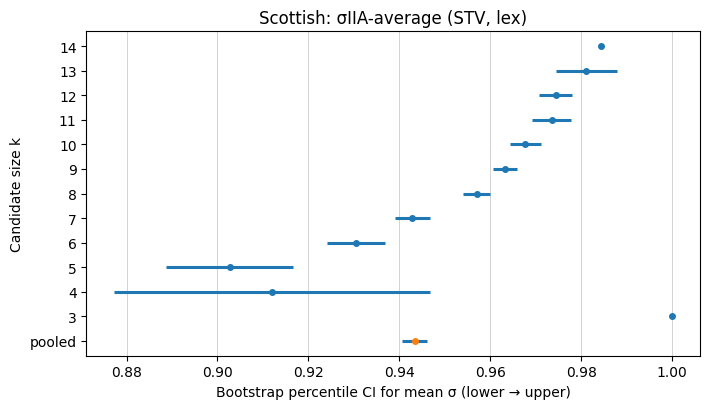

In [7]:
fig, ax = plot_horizontal_bootstrap_intervals(
    "bootstrap_cis_sigma_IIA_average.csv",
    rule="stv",
    tiebreak="lex",
    include_pooled=True,
    title="Scottish: σIIA-average (STV, lex)"
)
plt.show()


In [8]:
boot, ci = percentile_bootstrap_ci_from_json_in_cwd(
    filename="sigma_IIA_average/borda/METRIC_sigma_IIA_average__ELECTION_TYPE_borda__TIEBREAK_lex_output.json",
    candidate_size=8,   # pick 3,5,6,... or None to pool
    B=5000,
    alpha=0.05,
    seed=0
)

print("CI:", ci)
print("first 10 boot means:", boot[:10])


CI: (0.9894179894179893, 0.9927823786519439)
first 10 boot means: [0.989993098688751, 0.9910858063031978, 0.9930411778237864, 0.9912583390844261, 0.9924660685530251, 0.9889866574649182, 0.9913446054750402, 0.9903956751782839, 0.9885265700483093, 0.9909707844490454]


In [9]:
for x in range(3, 15):
    boot, ci = percentile_bootstrap_ci_from_json_in_cwd(
        filename="sigma_IIA_average/2-approval/METRIC_sigma_IIA_average__ELECTION_TYPE_2-approval__TIEBREAK_lex_output.json",
        candidate_size=x,   # pick 3,5,6,... or None to pool
        B =1000,
        alpha=0.05,
        seed=0
    )

    print(f"candidate_size={x} CI:", ci)

candidate_size=3 CI: (1.0, 1.0)
candidate_size=4 CI: (0.8541666666666666, 0.9375)
candidate_size=5 CI: (0.9184848484848487, 0.9454545454545455)
candidate_size=6 CI: (0.9491869918699187, 0.9626829268292684)
candidate_size=7 CI: (0.9599459642012834, 0.9670381627828436)
candidate_size=8 CI: (0.9675638371290545, 0.9741775937428112)
candidate_size=9 CI: (0.9716168953457089, 0.9771993543179985)
candidate_size=10 CI: (0.9762882447665056, 0.9820450885668276)
candidate_size=11 CI: (0.9756021756021757, 0.9844599844599846)
candidate_size=12 CI: (0.978030303030303, 0.9848484848484849)
candidate_size=13 CI: (0.9790209790209791, 0.9920357420357421)
candidate_size=14 CI: (0.9908424908424909, 0.9908424908424909)


Code for Confidence rectangle

In [10]:
import os, json
import numpy as np

def bootstrap_confidence_rectangle_from_two_jsons(
    file_iia,                 # e.g. "sigma_IIA_average/borda/METRIC_...json"
    file_um,                  # e.g. "sigma_UM_average_asin/borda/METRIC_...json"
    candidate_size=None,      # int like 8, or None to pool across sizes
    B=5000,
    alpha=0.05,
    seed=0,
    return_raw=False,
):
    """
    Returns:
      boot_means: np.ndarray with shape (B, 2)
      rect: ((L1,U1),(L2,U2)) where 1=IIA, 2=UM
      meta: dict with N used + candidate sizes included
      optionally: (x_raw, y_raw) if return_raw=True
    """
    path_iia = os.path.join(STATS_DIR, file_iia)
    path_um  = os.path.join(STATS_DIR, file_um)

    with open(path_iia, "r") as f:
        obj_iia = json.load(f)
    with open(path_um, "r") as f:
        obj_um = json.load(f)

    # decide which candidate sizes to use
    if candidate_size is None:
        sizes = sorted(set(obj_iia.keys()) & set(obj_um.keys()), key=int)
    else:
        k = str(candidate_size)
        if k not in obj_iia:
            raise KeyError(f"candidate_size={candidate_size} not found in IIA json. Available: {sorted(obj_iia.keys(), key=int)}")
        if k not in obj_um:
            raise KeyError(f"candidate_size={candidate_size} not found in UM json. Available: {sorted(obj_um.keys(), key=int)}")
        sizes = [k]

    # build aligned pairs (sigma_IIA, sigma_UM) using election-id intersection
    pairs = []
    used_counts = {}
    for k in sizes:
        d_iia = obj_iia[k]
        d_um  = obj_um[k]
        common_ids = set(d_iia.keys()) & set(d_um.keys())
        used_counts[k] = len(common_ids)
        for eid in common_ids:
            pairs.append((float(d_iia[eid]), float(d_um[eid])))

    X = np.asarray(pairs, dtype=float)
    n = len(X)
    if n == 0:
        raise ValueError("No overlapping elections between the two metrics (after filtering).")

    rng = np.random.default_rng(seed)
    boot = np.empty((B, 2), dtype=float)

    for b in range(B):
        idx = rng.integers(0, n, size=n)   # sample n pairs with replacement
        boot[b, :] = X[idx, :].mean(axis=0)

    # quantiles for each coordinate, using alpha/4 and 1-alpha/4
    q_lo, q_hi = alpha/4.0, 1.0 - alpha/4.0
    L1, L2 = np.quantile(boot, q_lo, axis=0)
    U1, U2 = np.quantile(boot, q_hi, axis=0)

    rect = ((float(L1), float(U1)), (float(L2), float(U2)))
    boot_means = boot
    x_raw = X[:, 1]
    y_raw = X[:, 0]

    meta = {
        "N_pairs": n,
        "candidate_size": candidate_size,
        "sizes_used": sizes,
        "overlap_counts_by_size": used_counts,
    }
    if return_raw:
        return boot_means, rect, meta, (x_raw, y_raw)
    return boot_means, rect, meta


In [11]:
boot_means, rect, meta = bootstrap_confidence_rectangle_from_two_jsons(
    file_iia="sigma_IIA_average/borda/METRIC_sigma_IIA_average__ELECTION_TYPE_borda__TIEBREAK_lex_output.json",
    file_um ="sigma_UM_average_asin/borda/METRIC_sigma_UM_average_asin__ELECTION_TYPE_borda__TIEBREAK_lex_output.json",
    candidate_size=9,
    B=5000,
    alpha=0.05,
    seed=0
)

print("meta:", meta)
print("rect:", rect)



meta: {'N_pairs': 118, 'candidate_size': 9, 'sizes_used': ['9'], 'overlap_counts_by_size': {'9': 118}}
rect: ((0.9923997847726672, 0.995325531342481), (0.9971445472204624, 0.9982508883850844))


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pooled_rectangles_swapped_axes(
    rules=("stv","plurality","borda"),
    tiebreak="lex",
    metric_iia="sigma_IIA_average",
    metric_um="sigma_UM_average_asin",
    B=5000,
    alpha=0.05,
    seed=0,
    show_boot_cloud=True,
    cloud_alpha=0.08,
    max_cloud_points=2000,
    equal_aspect=False,   
):
    results=[]

    
    for rule in rules:
        file_iia=f"{metric_iia}/{rule}/METRIC_{metric_iia}__ELECTION_TYPE_{rule}__TIEBREAK_{tiebreak}_output.json"
        file_um =f"{metric_um}/{rule}/METRIC_{metric_um}__ELECTION_TYPE_{rule}__TIEBREAK_{tiebreak}_output.json"

        boot_means, rect, meta = bootstrap_confidence_rectangle_from_two_jsons(
            file_iia=file_iia,
            file_um=file_um,
            candidate_size=None,
            B=B,
            alpha=alpha,
            seed=seed
        )

        boot=np.asarray(boot_means)
        results.append((rule,boot,rect,meta))

    
    all_x=np.concatenate([r[1][:,1] for r in results])   # UM
    all_y=np.concatenate([r[1][:,0] for r in results])   # IIA

    rect_x=np.concatenate([[r[2][1][0],r[2][1][1]] for r in results])  # UM bounds
    rect_y=np.concatenate([[r[2][0][0],r[2][0][1]] for r in results])  # IIA bounds

    xmin=min(all_x.min(),rect_x.min())
    xmax=max(all_x.max(),rect_x.max())
    ymin=min(all_y.min(),rect_y.min())
    ymax=max(all_y.max(),rect_y.max())

    
    pad_x=0.02*(xmax-xmin)
    pad_y=0.02*(ymax-ymin)
    xmin-=pad_x; xmax+=pad_x
    ymin-=pad_y; ymax+=pad_y

    
    fig,axes=plt.subplots(1,len(rules),figsize=(5.2*len(rules),4.6),constrained_layout=True)
    if len(rules)==1:
        axes=[axes]

    for ax,(rule,boot,rect,meta) in zip(axes,results):

        (L1,U1),(L2,U2)=rect  # IIA first, UM second

        # scatter cloud (swap coords!)
        if show_boot_cloud:
            if len(boot)>max_cloud_points:
                rng=np.random.default_rng(seed)
                boot_plot=boot[rng.choice(len(boot),max_cloud_points,replace=False)]
            else:
                boot_plot=boot
            ax.scatter(boot_plot[:,1],boot_plot[:,0],s=10,alpha=cloud_alpha)

        # rectangle (swap axes)
        ax.add_patch(
            plt.Rectangle(
                (L2,L1),        
                U2-L2,          
                U1-L1,    
                fill=False,
                linewidth=2
            )
        )

        # center point (swap)
        ax.scatter([boot[:,1].mean()],[boot[:,0].mean()],s=60)

        ax.set_title(f"{rule.upper()} (pooled sizes, {tiebreak})")
        ax.set_xlabel(r"$\sigma_{\mathrm{UM}}$ mean")
        ax.set_ylabel(r"$\sigma_{\mathrm{IIA}}$ mean")

        ax.set_xlim(xmin,xmax)
        ax.set_ylim(ymin,ymax)

        if equal_aspect:
            ax.set_aspect('equal', adjustable='box')

        ax.grid(True,linewidth=0.4)

    return fig,axes


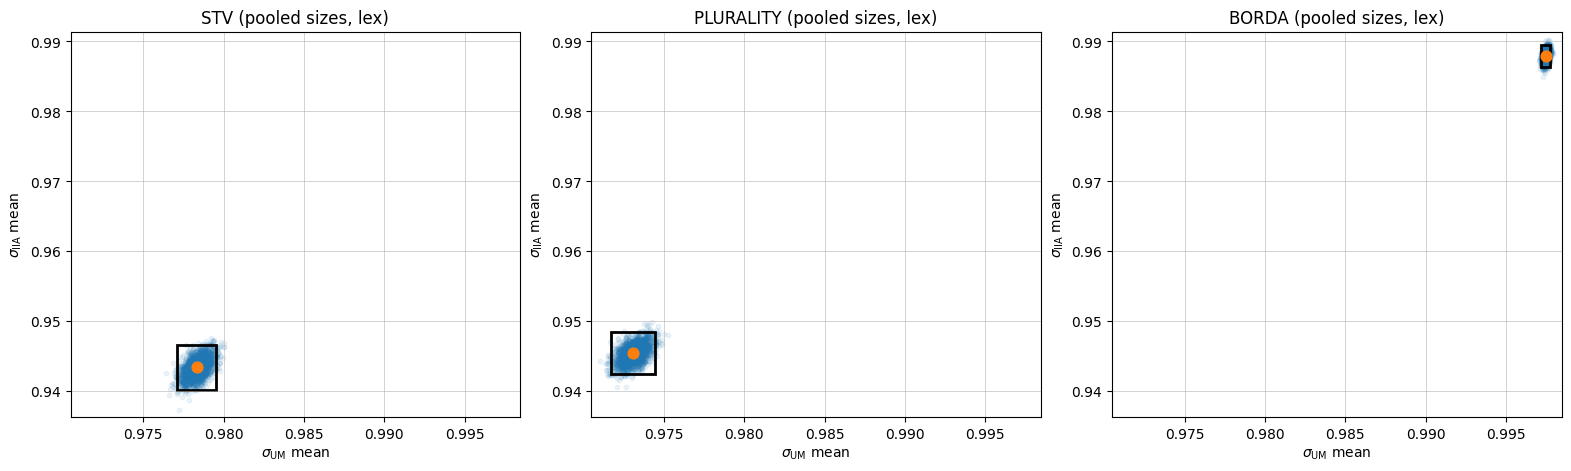

In [13]:
fig,axes = plot_pooled_rectangles_swapped_axes(
    rules=("stv","plurality","borda"),
    tiebreak="lex",
    B=5000,
    alpha=0.05,
    seed=0,
    show_boot_cloud=True,
    equal_aspect=False   # set True for paper geometry
)
plt.show()


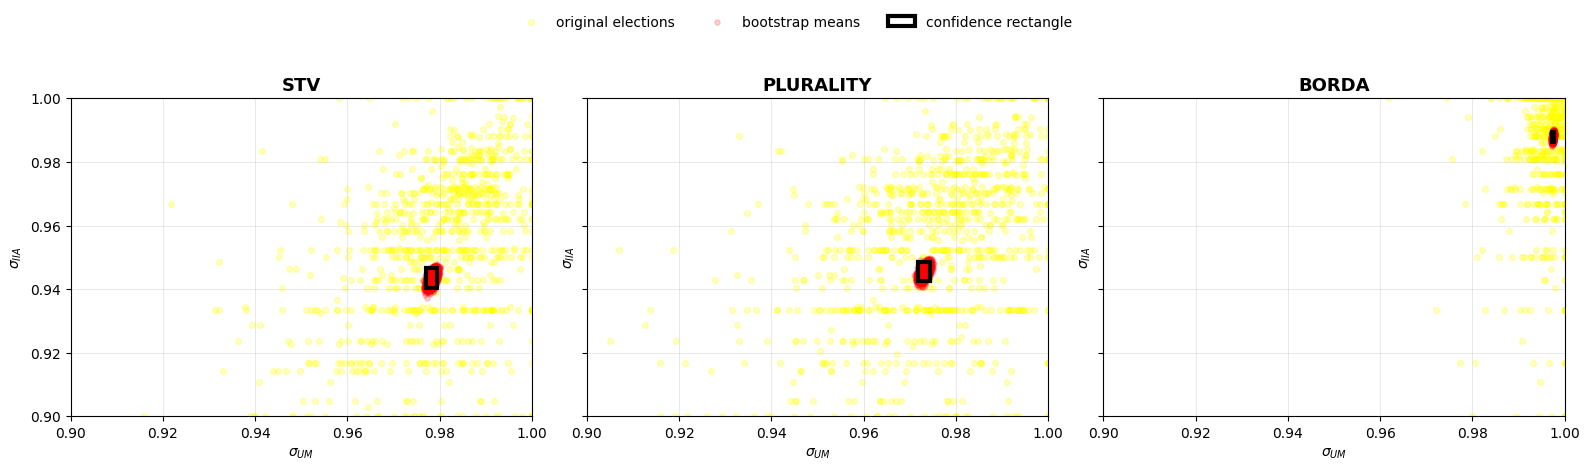

In [14]:
import matplotlib.pyplot as plt

rules = ["stv","plurality","borda"]
color_map = {
    "stv": "black",
    "plurality": "black",
    "borda": "black"
}


fig, axes = plt.subplots(1,3, figsize=(16,4.5), sharex=True, sharey=True)

for ax, rule in zip(axes, rules):

    file_iia = f"{STATS_DIR}/sigma_IIA_average/{rule}/METRIC_sigma_IIA_average__ELECTION_TYPE_{rule}__TIEBREAK_lex_output.json"
    file_um  = f"{STATS_DIR}/sigma_UM_average_asin/{rule}/METRIC_sigma_UM_average_asin__ELECTION_TYPE_{rule}__TIEBREAK_lex_output.json"

    boot, rect, meta, (x_raw, y_raw) = bootstrap_confidence_rectangle_from_two_jsons(
        file_iia=file_iia,
        file_um=file_um,
        candidate_size=None,
        B=5000,
        alpha=0.05,
        seed=0,
        return_raw=True
    )

    (L_iia, U_iia), (L_um, U_um) = rect

    # Raw elections
    ax.scatter(
        x_raw, y_raw,
        s=18,
        alpha=0.25,
        color="yellow",
        label="original elections",
        zorder=1
    )

    # Bootstrap means (red)
    ax.scatter(
        boot[:,1], boot[:,0],
        s=14,
        alpha=0.18,
        color="red",
        label="bootstrap means",
        zorder=2
    )

    # Rectangle
    ax.add_patch(
        plt.Rectangle(
            (L_um, L_iia),
            U_um-L_um,
            U_iia-L_iia,
            fill=False,
            linewidth=3,
            edgecolor="black",
            label="confidence rectangle",
            zorder=3
        )
    )

    
   
    ax.set_title(rule.upper(), fontsize=13, fontweight="bold")

    # ⭐ FIXED AXES
    ax.set_xlim(0.9,1.0)
    ax.set_ylim(0.9,1.0)

    ax.set_xlabel(r"$\sigma_{UM}$")
    ax.set_ylabel(r"$\sigma_{IIA}$")
    ax.grid(True, linewidth=0.5, alpha=0.4)

# Legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5,1.05)
)

fig.tight_layout(rect=[0,0,1,0.92])
plt.show()
